# Pipeline de Machine Learning con scikit-learn

**Dataset:** `Most_Streamed_Spotify_Songs_2024.csv`  
**Objetivo:** estimar `Track Score` mediante regresión.  
**Metodología:** primeras dos etapas de CRISP-DM y un flujo
reproducible de preparación, entrenamiento y evaluación.

## tl;dr

La ejecución validada usa **4,598 canciones** después de eliminar
dos duplicados. El pipeline obtiene **MAE 9.07**, **RMSE 19.46** y
**R² 0.732** en 920 filas de prueba. Su MAE mejora **53.44%** frente
a un regresor base que siempre predice la mediana.

El resultado es exploratorio: identifica asociaciones en las
señales de plataformas, no demuestra qué causa el éxito de una
canción.

## 1. Contexto y métodos

### Business Understanding

Un equipo de música necesita priorizar canciones con mayor
potencial de rendimiento digital. Usaremos `Track Score` como una
medida agregada de rendimiento y construiremos un modelo que la
estime a partir de conteos, popularidad, fecha de lanzamiento y si
la canción es explícita.

**Criterio de éxito:** el modelo debe reducir el MAE frente a
`DummyRegressor(strategy="median")`. También reportamos RMSE y R².

### Supuestos clave

- `Track Score` es una aproximación útil al rendimiento global.
- Las filas se consideran observaciones independientes.
- `All Time Rank` se excluye porque está estrechamente ligado al
  objetivo y generaría fuga de información.
- Nombres, artista, álbum e ISRC se excluyen por su alta cardinalidad.
- La evaluación describe este CSV; no garantiza generalización a
  lanzamientos futuros.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn import set_config

from spotify_sklearn_pipeline.data import (
    CATEGORICAL_COLUMNS,
    CONTINUOUS_COLUMNS,
    COUNT_COLUMNS,
    DATE_COLUMNS,
    LEAKAGE_COLUMNS,
    MODEL_FEATURES,
    filter_training_rows,
    load_dataset,
)
from spotify_sklearn_pipeline.pipeline import build_model_pipeline
from spotify_sklearn_pipeline.train import train_and_evaluate

CSV_NAME = "Most_Streamed_Spotify_Songs_2024.csv"
current = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate
    for candidate in [current, *current.parents]
    if (candidate / CSV_NAME).is_file()
)
CSV_PATH = PROJECT_ROOT / CSV_NAME
NOTEBOOK_ARTIFACTS = PROJECT_ROOT / "artifacts" / "notebook"

pd.set_option("display.max_columns", 12)
plt.style.use("seaborn-v0_8-whitegrid")
print(f"Proyecto: {PROJECT_ROOT}")
print(f"Fuente: {CSV_PATH.name}")

Proyecto: C:\Users\Julio\Documents\GitHub\actividad1MLE\.worktrees\spotify-pipeline
Fuente: Most_Streamed_Spotify_Songs_2024.csv


## 2. Data Understanding

La extracción usa `latin-1`, que es la codificación requerida por
el archivo. Primero revisamos tamaño, muestra, tipos, duplicados y
valores faltantes antes de construir el modelo.

In [2]:
data = load_dataset(CSV_PATH)
print(f"Dimensiones: {data.shape[0]:,} filas × {data.shape[1]} columnas")
print(f"Duplicados exactos: {data.duplicated().sum():,}")
display(data.head(5))

Dimensiones: 4,600 filas × 29 columnas
Duplicados exactos: 2


,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,...,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,...,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,...,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,...,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,...,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,...,"4,493,884","7,006","207,179","457,017",NaN,1


In [3]:
column_profile = pd.DataFrame({
    "tipo": data.dtypes.astype(str),
    "faltantes": data.isna().sum(),
    "porcentaje_faltante": data.isna().mean().mul(100).round(2),
    "valores_unicos": data.nunique(dropna=True),
}).sort_values("porcentaje_faltante", ascending=False)
display(column_profile)

,tipo,faltantes,porcentaje_faltante,valores_unicos
TIDAL Popularity,float64,4600,100.00,0
Soundcloud Streams,str,3333,72.46,1265
SiriusXM Spins,str,2123,46.15,689
Pandora Track Stations,str,1268,27.57,2975
TikTok Posts,str,1173,25.50,3318
Pandora Streams,str,1106,24.04,3491
Amazon Playlist Count,float64,1055,22.93,147
YouTube Playlist Reach,str,1009,21.93,3458
TikTok Views,str,981,21.33,3616
TikTok Likes,str,980,21.30,3615


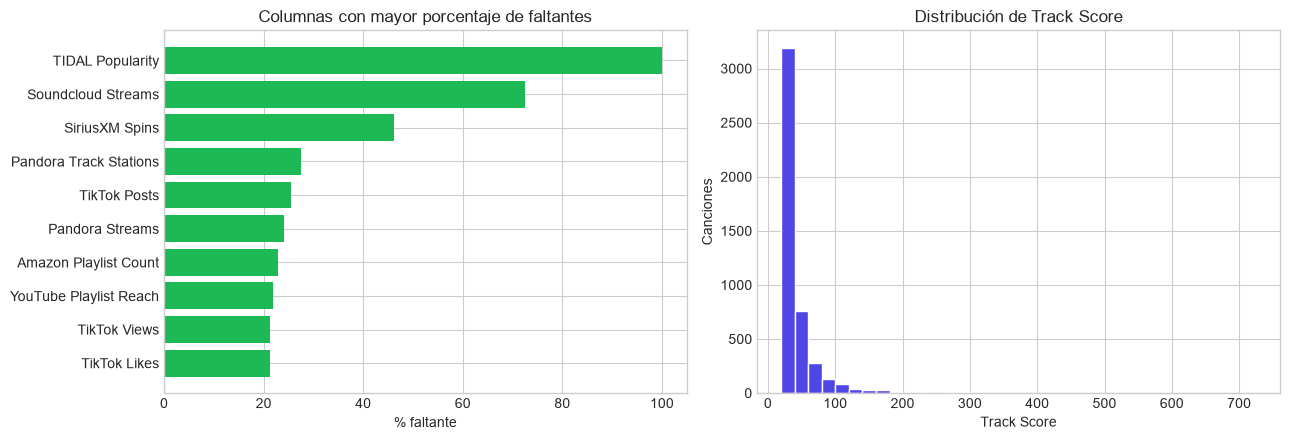

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
missing_top = column_profile.head(10).sort_values("porcentaje_faltante")
axes[0].barh(missing_top.index, missing_top["porcentaje_faltante"], color="#1DB954")
axes[0].set_title("Columnas con mayor porcentaje de faltantes")
axes[0].set_xlabel("% faltante")

axes[1].hist(data["Track Score"], bins=35, color="#4F46E5", edgecolor="white")
axes[1].set_title("Distribución de Track Score")
axes[1].set_xlabel("Track Score")
axes[1].set_ylabel("Canciones")
plt.tight_layout()
plt.show()

### Hallazgos de calidad

- Los conteos de plataformas llegan como texto con comas y deben
  convertirse a números.
- `Release Date` requiere extracción de componentes temporales.
- Hay faltantes importantes; `TIDAL Popularity` está totalmente
  vacía y no se utiliza.
- Existen dos duplicados exactos.
- `Track Score` presenta una cola derecha; por eso MAE es una métrica
  principal más interpretable que depender solo de RMSE.

## 3. Preparación y separación

El filtrado elimina duplicados y objetivos inválidos. Después se
reserva 20% para prueba con semilla 42. Las imputaciones, escalado y
codificación se aprenden **solo** al ajustar el conjunto de
entrenamiento porque viven dentro del pipeline.

In [5]:
X, y, audit = filter_training_rows(data)
preparation_summary = pd.DataFrame({
    "grupo": ["Conteos", "Continuas", "Fecha", "Categóricas"],
    "columnas": [
        len(COUNT_COLUMNS),
        len(CONTINUOUS_COLUMNS),
        len(DATE_COLUMNS),
        len(CATEGORICAL_COLUMNS),
    ],
    "tratamiento": [
        "Quitar comas → mediana → log1p → escala",
        "Mediana → escala",
        "Año/mes/día/antigüedad → imputación → escala",
        "Moda → one-hot",
    ],
})
print("Auditoría del filtrado:", audit)
print("Columnas excluidas:", ", ".join(LEAKAGE_COLUMNS))
display(preparation_summary)

Auditoría del filtrado: {'input_rows': 4600, 'duplicates_removed': 2, 'invalid_target_rows_removed': 0, 'output_rows': 4598}
Columnas excluidas: All Time Rank, Track, Album Name, Artist, ISRC, TIDAL Popularity


,grupo,columnas,tratamiento
0,Conteos,16,Quitar comas → mediana → log1p → escala
1,Continuas,4,Mediana → escala
2,Fecha,1,Año/mes/día/antigüedad → imputación → escala
3,Categóricas,1,Moda → one-hot


## 4. Pipeline y diagrama

El objeto siguiente es el pipeline real entrenado. El diagrama
generado por sklearn permite expandir cada rama del
`ColumnTransformer` y comprobar cómo se manejan los distintos tipos
de variables.

In [6]:
result = train_and_evaluate(CSV_PATH, NOTEBOOK_ARTIFACTS)
set_config(display="diagram")
result.pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prepare', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Spotify Streams','Spotify Playlist Count','Spotify Playlist Reach',..., 'Amazon Playlist Count','Release Date','Explicit Track']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('counts', ...), ('continuous', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passed

## 5. Resultados

La comparación usa exactamente las mismas 920 canciones de prueba
para el bosque aleatorio y la línea base.

In [7]:
metrics_table = pd.DataFrame({
    "Random Forest": result.metrics["model"],
    "Baseline (mediana)": result.metrics["baseline"],
}).T
display(metrics_table.style.format({
    "mae": "{:.3f}", "rmse": "{:.3f}", "r2": "{:.3f}"
}))
print(
    "Mejora de MAE frente al baseline: "
    f"{result.metrics['mae_improvement_percent']:.2f}%"
)
print("Partición:", result.metrics["split"])

,mae,rmse,r2
Random Forest,9.074,19.459,0.732
Baseline (mediana),19.491,40.047,-0.134


Mejora de MAE frente al baseline: 53.44%
Partición: {'train_rows': 3678, 'test_rows': 920, 'test_size': 0.2, 'random_state': 42}


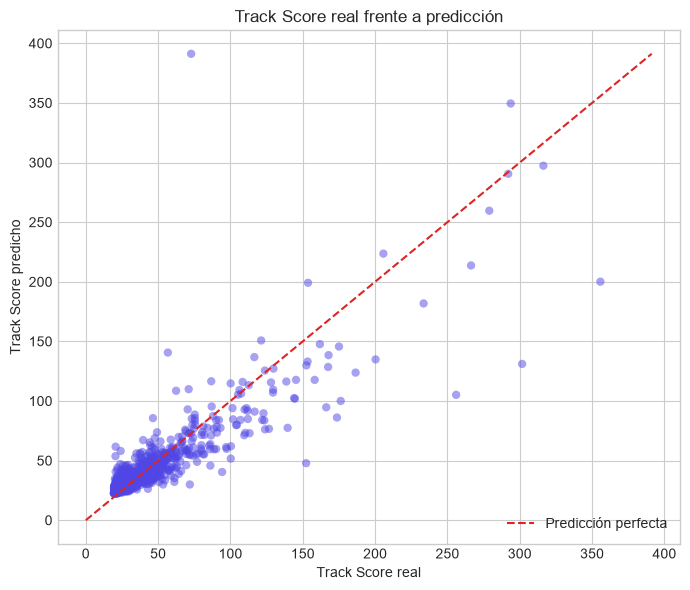

In [8]:
predictions = result.predictions
maximum = max(
    predictions["actual_track_score"].max(),
    predictions["predicted_track_score"].max(),
)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    predictions["actual_track_score"],
    predictions["predicted_track_score"],
    alpha=0.5,
    color="#4F46E5",
    edgecolor="none",
)
ax.plot([0, maximum], [0, maximum], "--", color="#DC2626", label="Predicción perfecta")
ax.set(
    title="Track Score real frente a predicción",
    xlabel="Track Score real",
    ylabel="Track Score predicho",
)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Takeaways y limitaciones

- El pipeline reduce el MAE de **19.49 a 9.07**, una mejora de
  **53.44%** frente a la mediana.
- Un R² de **0.732** indica que el modelo captura una parte
  sustancial de la variación del conjunto de prueba, aunque aún hay
  errores grandes visibles en canciones con scores extremos.
- El pipeline empaqueta conversión de conteos, imputación,
  ingeniería de fecha, one-hot encoding y el regresor; por eso puede
  reutilizarse con `joblib` sin repetir preparación manual.
- La separación es aleatoria, no temporal. Una validación futura
  debería probar lanzamientos posteriores y revisar estabilidad por
  artista y plataforma.
- Las señales de plataformas pueden formar parte del cálculo del
  propio `Track Score`; el modelo sirve para demostrar el flujo
  técnico, no para afirmar causalidad.